# <span style="color:purple; font-weight:bold; text-decoration:underline;"> North Pacific Oxidant Climatologies

### <span style='color:purple'> Imports

In [2]:
# Third-party imports
import xarray as xr

### <span style='color:purple'> Opening Regional and Variable DataArrays

In [3]:
NPAC = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPO/coastline_corrected_NPAC_mask.nc')    
East_Asia = xr.open_dataarray('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/weighting_and_masks/CJK_binary_assign_coords.nc')
area = xr.open_dataarray('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/weighting_and_masks/AREA.nc')

In [4]:
O3_1970 = xr.open_dataset('/glade/work/jzweifel/data_1970/h5_concat_1970.nc')['O3'].where(East_Asia).groupby('time.month').mean(dim=['time']).roll(month=-1)
OH_1970 = xr.open_dataset('/glade/work/jzweifel/data_1970/h5_concat_1970.nc')['OH'].where(East_Asia).groupby('time.month').mean(dim=['time']).roll(month=-1)
H2O2_1970 = xr.open_dataset('/glade/work/jzweifel/data_1970/h1_concat_1970.nc')['H2O2'].where(East_Asia).groupby('time.month').mean(dim=['time']).roll(month=-1)

### <span style='color:purple'> Plotting 1970 NPAC Oxidant Seasonalities

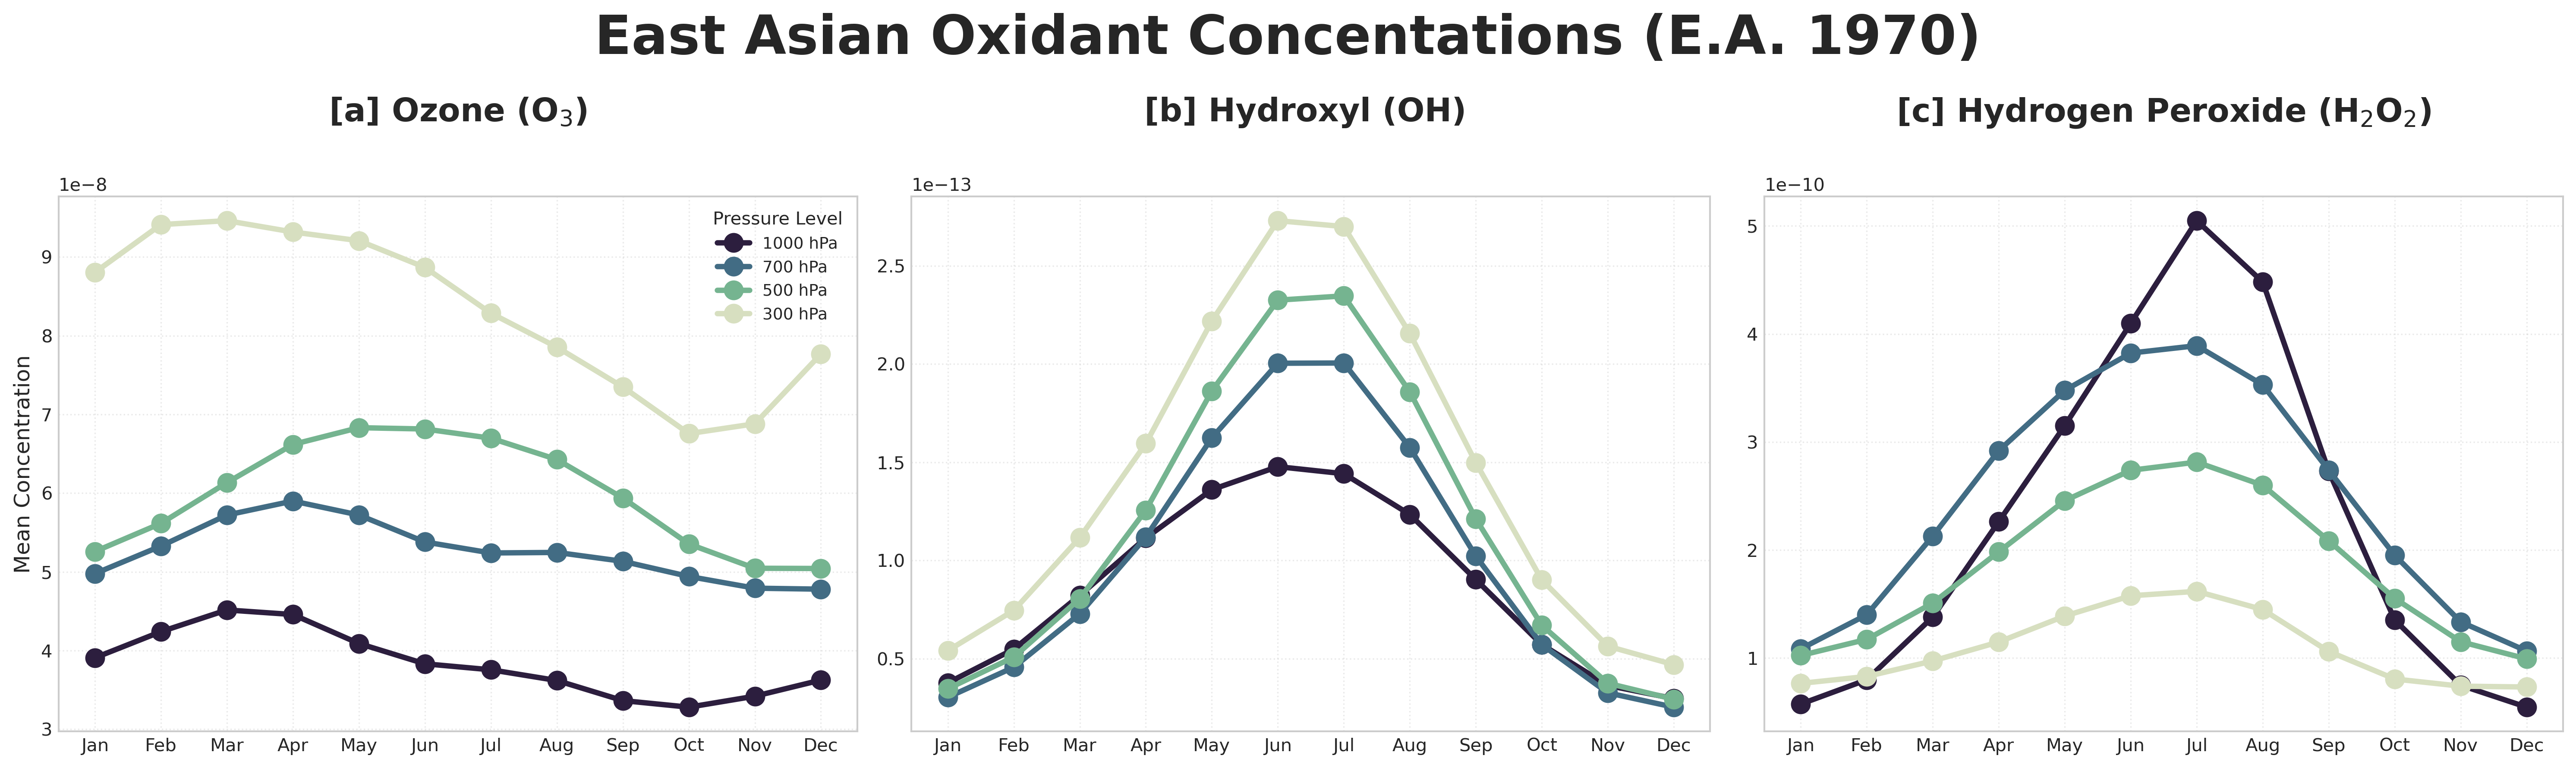

In [89]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import calendar
import seaborn as sns
import numpy as np

import calendar
months = calendar.month_abbr[1:]

# ---------------------------------------------------------
# Discrete cubehelix colors for pressure levels
# ---------------------------------------------------------
levels = [1000, 700, 500, 300]

level_colors_list = sns.cubehelix_palette(n_colors=len(levels), start=.5, rot=-.75, reverse=True)

# Map: 1000 → color0, 700 → color1, ..., 300 → color3
level_colors = {lev: color for lev, color in zip(levels, level_colors_list)}

# ---------------------------------------------------------
# Global style
# ---------------------------------------------------------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "legend.frameon": False,
    "lines.linewidth": 2,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.4
})

# ---------------------------------------------------------
# Inputs
# ---------------------------------------------------------
titles = [
    "[a] Ozone (O$_{3}$)",
    "[b] Hydroxyl (OH) ",
    "[c] Hydrogen Peroxide (H$_{2}$O$_{2}$)"
]

data_arrays = [O3_1970, OH_1970, H2O2_1970]

# ---------------------------------------------------------
# Figure and axes
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(20, 6), dpi=300, sharex=True)

# ---------------------------------------------------------
# O3 panel
# ---------------------------------------------------------
ax = axs[0]
da = O3_1970

ax.plot(months, da.sel(lev=1000, method='nearest').mean(['lat', 'lon']), color=level_colors[1000], marker='o', label="1000 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=700, method='nearest').mean(['lat', 'lon']), color=level_colors[700], marker='o', label="700 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=500, method='nearest').mean(['lat', 'lon']), color=level_colors[500], marker='o', label="500 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=300, method='nearest').mean(['lat', 'lon']), color=level_colors[300], marker='o', label="300 hPa", linewidth=3, markersize=10)

ax.set_title(titles[0], fontsize=18, y=1.12)
ax.set_ylabel("Mean Concentration", fontsize=12)

# ---------------------------------------------------------
# OH panel
# ---------------------------------------------------------
ax = axs[1]
da = OH_1970

ax.plot(months, da.sel(lev=1000, method='nearest').mean(['lat','lon']),color=level_colors[1000], marker='o', label="1000 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=700, method='nearest').mean(['lat','lon']), color=level_colors[700], marker='o', label="700 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=500, method='nearest').mean(['lat','lon']), color=level_colors[500], marker='o', label="500 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=300, method='nearest').mean(['lat','lon']), color=level_colors[300], marker='o', label="300 hPa", linewidth=3, markersize=10)

ax.set_title(titles[1], fontsize=18, y=1.12)

# ---------------------------------------------------------
# H2O2 panel
# ---------------------------------------------------------
ax = axs[2]
da = H2O2_1970

ax.plot(months, da.sel(lev=1000, method='nearest').mean(['lat','lon']), color=level_colors[1000], marker='o', label="1000 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=700, method='nearest').mean(['lat','lon']), color=level_colors[700], marker='o', label="700 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=500, method='nearest').mean(['lat','lon']), color=level_colors[500], marker='o', label="500 hPa", linewidth=3, markersize=10)
ax.plot(months, da.sel(lev=300, method='nearest').mean(['lat','lon']),color=level_colors[300], marker='o', label="300 hPa", linewidth=3, markersize=10)

ax.set_title(titles[2], fontsize=18, y=1.12)

# ---------------------------------------------------------
# Legend (one unified)
# ---------------------------------------------------------
axs[0].legend(title="Pressure Level", loc="upper right", fontsize=9)

fig.suptitle('East Asian Oxidant Concentations (E.A. 1970)', fontsize=30, weight='bold')
fig.tight_layout()

plt.show()